> 🤖 **AI-Assisted** — Dependencies installation

In [165]:
# 1. Install dependencies
!pip install transformers datasets safetensors tqdm

> 🤖 **AI-Assisted** — Imports and base model loading functions

In [166]:
# 2. Imports and Device Setup
import os
import math
import random
import json
import html
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from typing import Generator, List, Dict, Any, Tuple
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import pandas as pd
# Set up device (Colab T4 GPU uses cuda)
device = "cpu" # Bypass MPS bug, use fast local CPU with batching!
print(f"Using device: {device}")

Using device: cpu


> ✍️ **My Work** — Base model loading utilities

In [167]:
def load_base_model(model_name="gpt2", device="cpu"):
    print(f"Loading base language model: {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()
    for param in model.parameters():
        param.requires_grad = False
    return model, tokenizer

def get_text_dataset(dataset_name="dair-ai/emotion", split="train"):
    print(f"Loading dataset: {dataset_name}...")
    dataset = load_dataset(dataset_name, split=split)

    return dataset

> ✍️ **My Work** — Base model loading utilities

In [168]:
model, tokenizer= load_base_model()

Loading base language model: gpt2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

> ✍️ **My Work** — Loading dataset

In [169]:
ds = get_text_dataset()

Loading dataset: dair-ai/emotion...


> ✍️ **My Work** — Initializing activations buffer

In [170]:
activations = []

> ✍️ **My Work** — This was to run locally on Mac later on I had to go for colab just to run more experiments without over heating

In [171]:

# def hook(instance, input, output):
#     """
#     hook to register activations of gpt2
#     """
#     activations.append(output)



> 🤖 **AI-Assisted** — This hook is batched to run on cuda

In [172]:
def batched_hook(instance, input, output):
    for b in range(output[0].size(0)):
        activations.append((output[0][b:b+1].cpu(),))



> ✍️ **My Work** — Device setup

In [173]:
device = "cuda"
model.to(device)
target_module = model.transformer.h[6]


> ✍️ **My Work** — Also first time interacting with feature level interactions

In [174]:

#target_module.register_forward_hook(hook)
target_module.register_forward_hook(batched_hook)


> ✍️ **My Work** — I explored it while experimenting with different datasets my goal was to try to have one without clipping just to fit all of the text into the context I wanted to use a labelled one to see if the SAE captures the labels

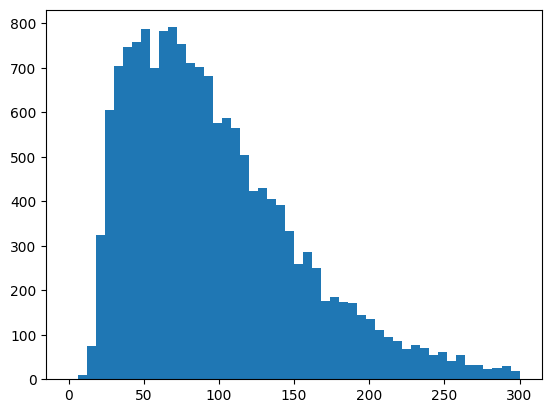

In [175]:
lengths=[]
for i in ds["text"]:
   lengths.append(len(i))
plt.hist(x= lengths, bins =50, range=(0,max(lengths)))
plt.show()

> ✍️ **My Work** — Visualization and plotting

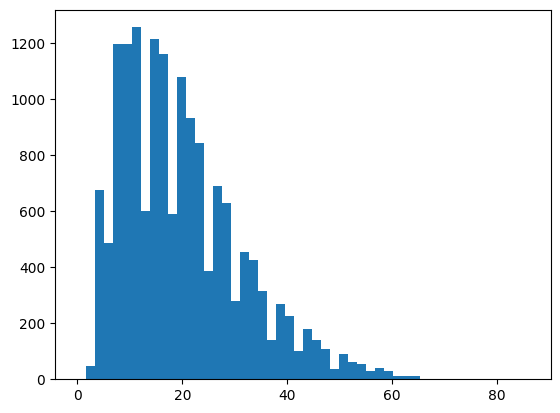

In [176]:
lengths=[]
for i in ds["text"]:
   lengths.append(len(tokenizer.encode(i)))
plt.hist(x= lengths, bins =50, range=(0,max(lengths)))
plt.show()

> ✍️ **My Work** — Extracting activations via forward pass

In [177]:

for i in tqdm(range(len(ds["text"]))):
    with torch.inference_mode():
        tokens = tokenizer.encode(ds["text"][i],
        max_length=1024,
        truncation = True,
        return_tensors="pt")
        tokens = tokens.to(device)
        model(tokens)


  0%|          | 0/16000 [00:00<?, ?it/s]

> ✍️ **My Work** — Saving activations to disk

In [ ]:
import torch

# save the activations list to a file
file_path = 'gpt2_activations.pt'
torch.save(activations, file_path)

print(f"Saved {len(activations)} activations to {file_path}")



> ✍️ **My Work** — Executing code block

In [178]:
print(activations[0][0].shape)



torch.Size([1, 768])


> 🤖 **AI-Assisted** — Emotion label mapping

In [179]:
emotion_mapping = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}


> ✍️ **My Work** — Computing mean activations per class

In [180]:
tensors = [[], [], [] , [] , [] ,[]]
for i in range(100):
    tensor = activations[i][0]
    tensor = torch.mean(tensor, dim =0)
    tn = torch.reshape(tensor, shape = (24,32))
    tensors[ds["label"][i]].append(tn)



> 🤖 **AI-Assisted** — Dataset Balancing & Utils

In [181]:
import random

# Find max class size to oversample
max_count = max(len(t) for t in tensors)
print(f"Balancing classes to max_count = {max_count}")

balanced_tensors = []
for label_list in tensors:
    if len(label_list) == 0:
        balanced_tensors.append([])
        continue
    # Randomly sample with replacement
    balanced_list = [random.choice(label_list) for _ in range(max_count)]
    balanced_tensors.append(balanced_list)

# Overwrite tensors for the training loop
tensors = balanced_tensors
for i, t in enumerate(tensors):
    print(f"Class {i} size: {len(t)}")


Balancing classes to max_count = 35
Class 0 size: 35
Class 1 size: 35
Class 2 size: 35
Class 3 size: 35
Class 4 size: 35
Class 5 size: 35


> ✍️ **My Work** — Executing code block

In [182]:
from numpy import average

> ✍️ **My Work** — Executing code block

In [183]:
for i in tensors:
    print(len((i)))

35
35
35
35
35
35


# Most of the activations seem non discrimnative and it is quite clear that there is a common acitvation pattern across all 6 emotions suggesting a common pattern
# it appears neagtive emotions are less overall "bright" but there is no clear features for them

> ✍️ **My Work** — Visualization and plotting

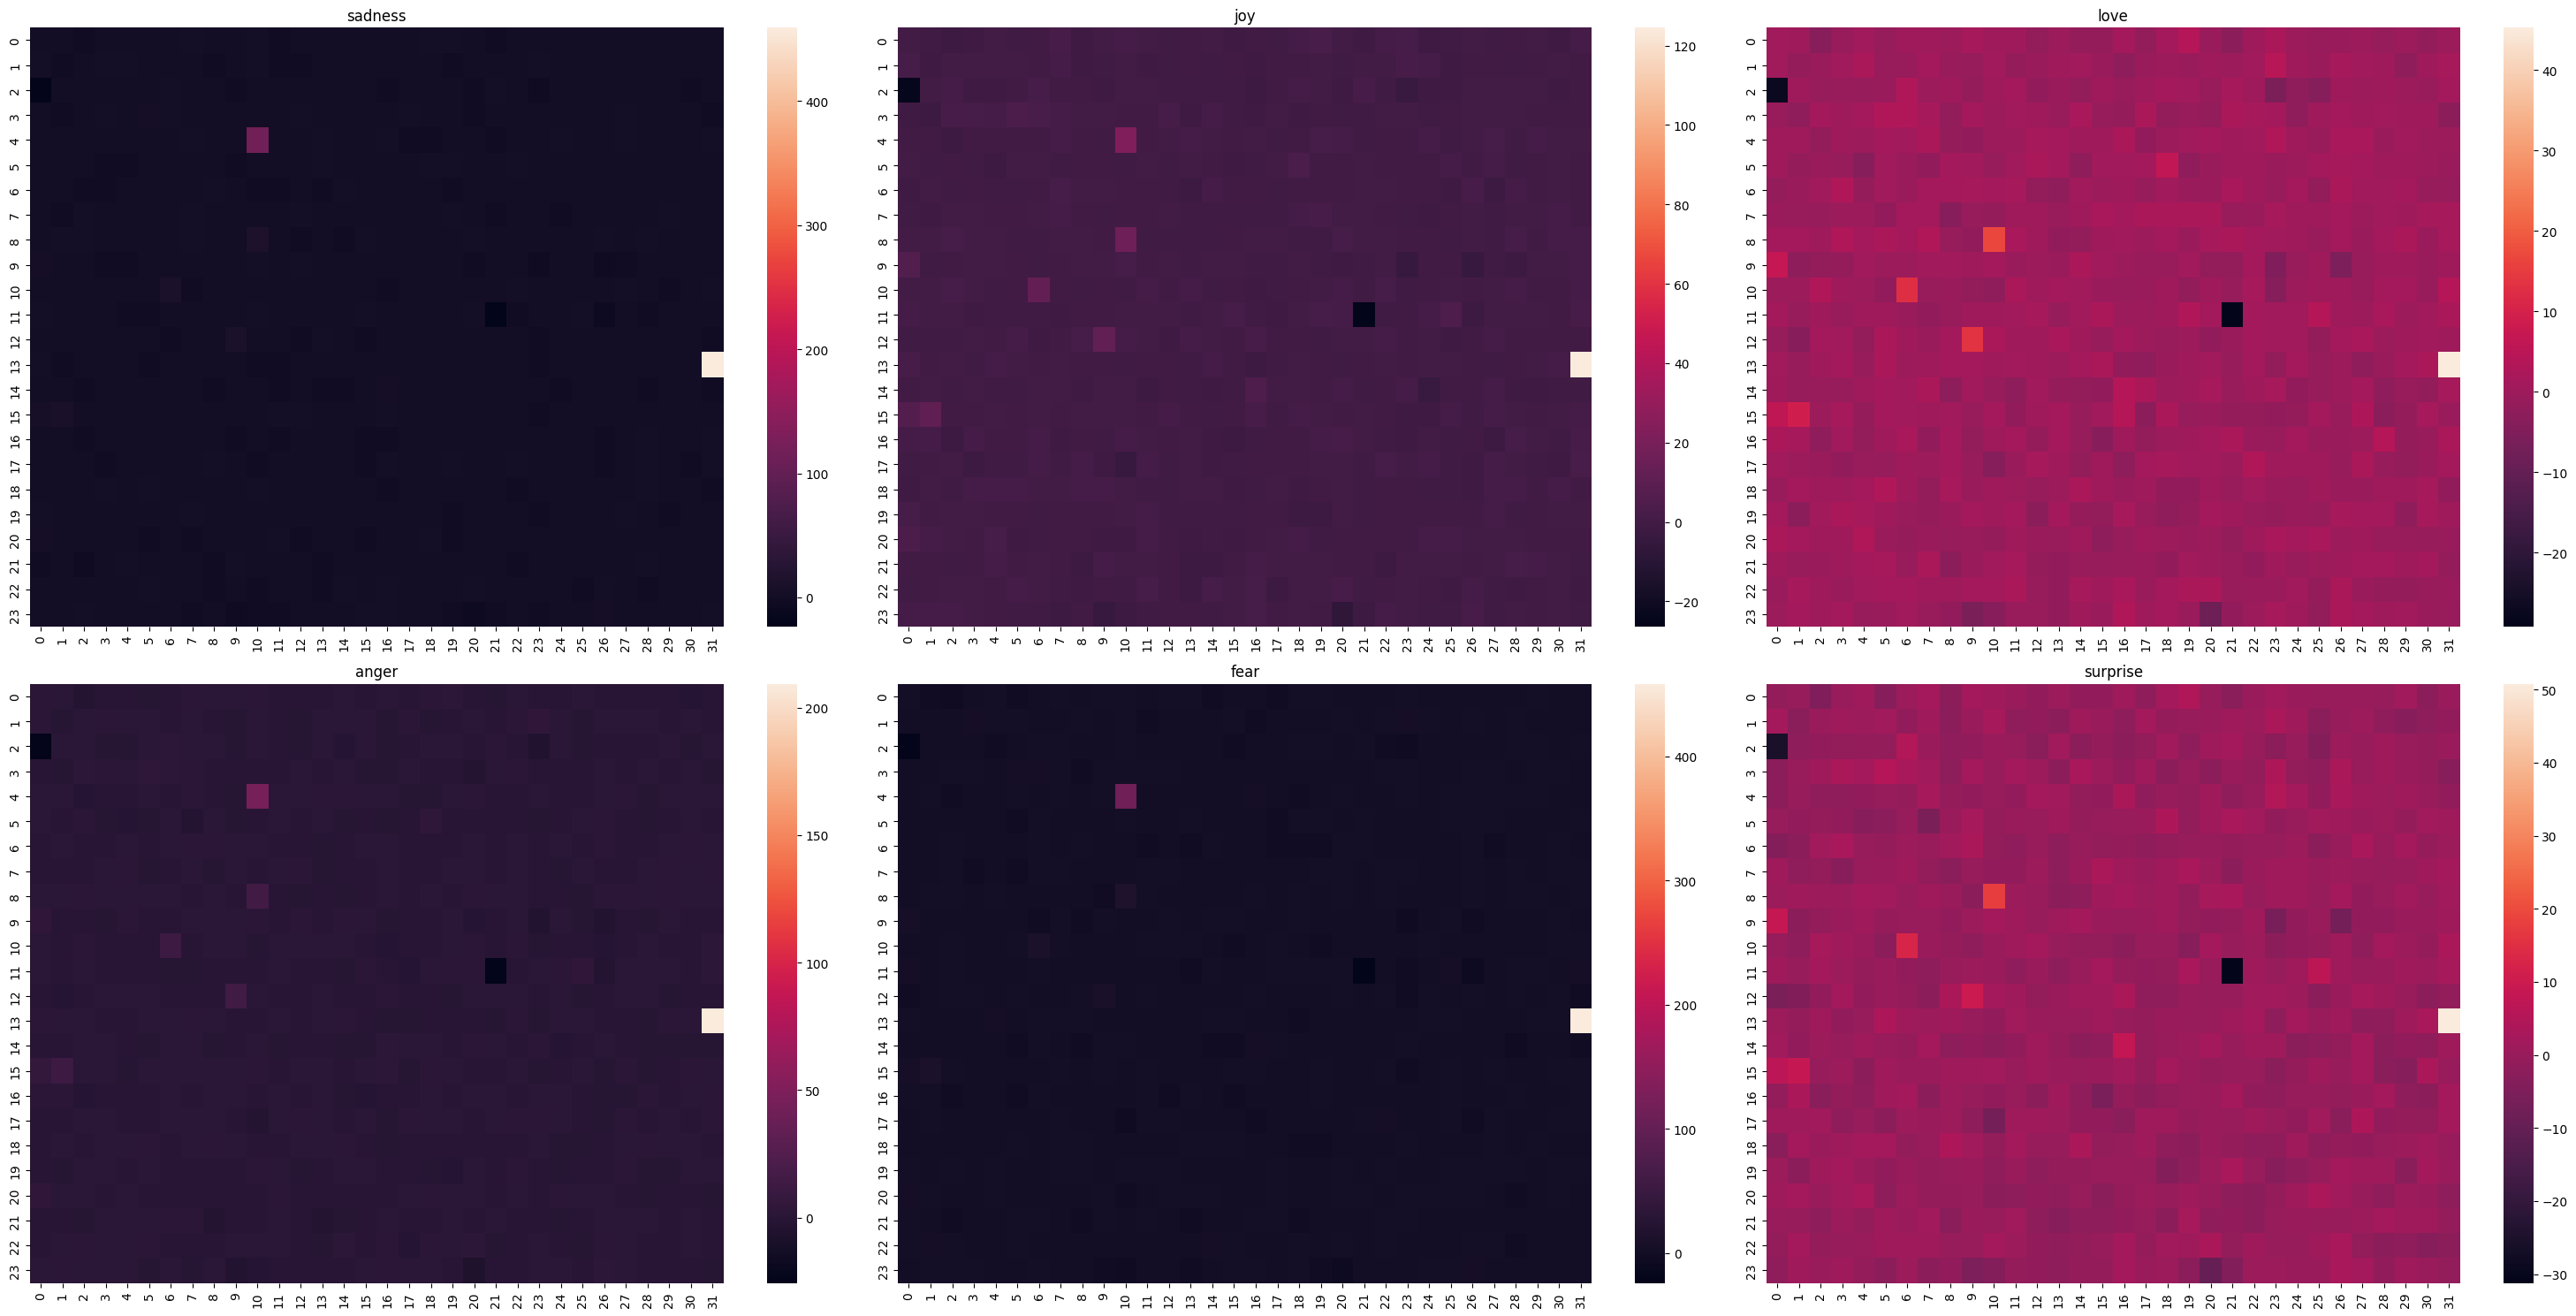

In [184]:

avg_emo_mat= {}
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(30, 15))
axes_flat = axes.flatten()

for i in range(6):
        averaged_matrix = torch.mean(torch.stack(tensors[i]), dim = 0).detach().clone()
        avg_emo_mat[emotion_mapping[i]] = averaged_matrix
        ax = axes_flat[i]
        sns.heatmap(averaged_matrix.cpu()
        ,ax = ax )
        ax.set_title(emotion_mapping[i])

plt.tight_layout()
plt.show()


> ✍️ **My Work** — Visualization and plotting

<Axes: >

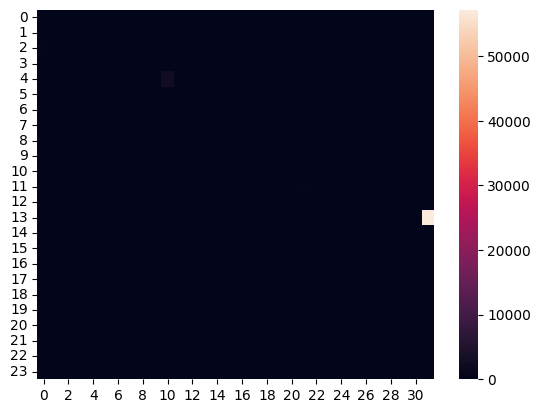

In [185]:
element_wise_s_j = avg_emo_mat["sadness"]* avg_emo_mat["joy"]
sns.heatmap(element_wise_s_j.cpu())

> ✍️ **My Work** — Visualization and plotting

<Axes: >

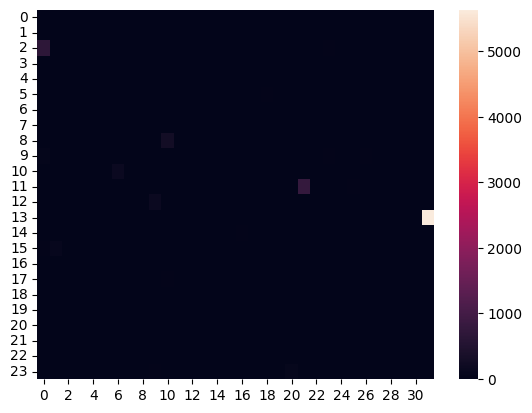

In [186]:
element_wise_l_j = avg_emo_mat["love"]* avg_emo_mat["joy"]
sns.heatmap(element_wise_l_j.cpu())


> ✍️ **My Work** — Executing code block


# 🧠 Sparse Autoencoder (SAE) Playground on Google Colab

This notebook guides you through building a **Sparse Autoencoder (SAE)** from scratch, training it, loading pre-trained weights, and visualizing the semantic concepts it learns.

## 📐 Mathematical Recap
- **Encoder**: Projects centered activations to a sparse latent space:  
  $$f(x) = \text{ReLU}\left((x - b_{dec}) W_{enc} + b_{enc}\right)$$
- **Decoder**: Reconstructs activations from sparse latents:  
  $$\hat{x} = f(x) W_{dec} + b_{dec}$$
- **Loss**: Minimizes MSE while penalizing L1 norm:  
  $$L = \|x - \hat{x}\|_2^2 + \lambda \|f(x)\|_1$$
- **Decoder Normalization**: Normalize rows of $W_{dec}$ (dictionary atoms) to unit L2 norm after each gradient step to prevent the model from cheating the L1 penalty:  
  $$\|W_{dec}[k, :]\|_2 = 1$$

> ✍️ **My Work** — SAE Model Definition

In [202]:
class SAE(nn.Module):
    """
     Batch dim =1
    """
    def __init__(self,d = 768, factor =4):
        super().__init__()
        self.encoder = nn.Parameter(torch.randn(
                                size = (d,  d*factor),
                                requires_grad=True,
                                dtype = torch.float
                            )/ math.sqrt(d*factor))
        self.decoder =nn.Parameter( torch.randn(
                                size = (d*factor, d),
                                requires_grad=True,
                                dtype = torch.float
                            ) / math.sqrt(d*factor))
        self.encb = nn.Parameter(torch.zeros(
                                size =  (d*factor, ),
                                requires_grad=True,
                                dtype = torch.float
                            ))
        self.decb = nn.Parameter(torch.zeros(
                                size =  (d, ),
                                requires_grad=True,
                                dtype = torch.float
                            ))


    def encode(self, x):
        #(batch , d ) x (d , d*F)
        h = (x- self.decb).matmul(self.encoder)   + self.encb
        h = F.relu(h)
        return h
    def decode(self, h):
        #(batch , d*F ) x (d*F , d)
        x = h.matmul(self.decoder) +  self.decb
        return x
    def forward(self, x):
        h = self.encode(x)
        x = self.decode(h)
        return x, h



> ✍️ **My Work** — Executing code block

In [203]:
torch.device(device)


device(type='cuda')

> ✍️ **My Work** — Executing code block

In [204]:
type(activations)

list

> 🤖 **AI-Assisted** — Data preparation for training

In [190]:
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# 1. PREPARE DATA (WITH POST-COLLECTION OVERSAMPLING)

# Grab the labels that correspond to our collected activations
labels = np.array(ds["label"][:len(activations)])
unique_labels = np.unique(labels)

# Find the size of the largest class
max_count = max((labels == lbl).sum() for lbl in unique_labels)

balanced_activations = []
for lbl in unique_labels:
    idx_for_lbl = np.where(labels == lbl)[0]
    # Oversample to match the largest class
    sampled_indices = np.random.choice(idx_for_lbl, size=max_count, replace=True)
    for idx in sampled_indices:
        balanced_activations.append(activations[idx])

print(f"Original sentences: {len(activations)}")
print(f"Balanced sentences (Oversampled): {len(balanced_activations)}")

# Now flatten the BALANCED activations
all_acts = torch.cat([act[0].squeeze(0) for act in balanced_activations], dim=0)

# Explicitly ensure it's 2D [num_tokens, hidden_dim] to prevent 1D tensor PyTorch errors downstream!
all_acts = all_acts.view(-1, 768)

# Create DataLoader
batch_size = 4096
dataset = TensorDataset(all_acts)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"Total balanced tokens for training: {len(all_acts)}")


Original sentences: 320015
Balanced sentences (Oversampled): 32172
Total balanced tokens for training: 32172


> ✍️ **My Work** — Executing code block

In [226]:
sae_model = SAE().to(device)



> ✍️ **My Work** — Optimizer setup

In [227]:
optimizer = torch.optim.AdamW(lr = 0.001, params = sae_model.parameters())

> 🤖 **AI-Assisted** — Training statistics helper

In [228]:
def print_statistics(batch_acts, mse_loss, h, loss):
  batch_variance = batch_acts.pow(2).mean() # or batch_acts.var()
  fve = 1.0 - (mse_loss / batch_variance)
  # 2. Calculate L0 (how many latents are non-zero?)
  # We use > 0.001 to account for tiny floating point noise
  l0_sparsity = (h > 0.001).float().sum(dim=-1).mean()
  print(f"Loss: {loss.item():.2f} | FVE: {fve.item():.2f} | L0: {l0_sparsity.item():.1f}")

> ✍️ **My Work** — Saving activations to disk

In [229]:
EPOCHS = 40
lmb = 0.005
for i in tqdm(range(EPOCHS)):

    total_loss = 0
    sae_model.train()

    for batch in dataloader:
        batch_acts = batch[0].to(device)
        #forward
        act_reconstruct, h  = sae_model(batch_acts)

        #loss
        mse_loss = F.mse_loss(act_reconstruct, batch_acts)
        sparsity_loss = h.abs().sum(dim=-1).mean()
        loss = mse_loss + lmb * sparsity_loss

        #zero grad
        optimizer.zero_grad()

        #backward
        loss.backward()

        #step
        optimizer.step()

        #print metrics to measure performance per batch
        print_statistics(batch_acts, mse_loss, h, loss)

    print(f"Loss at epoch {i+1} is {loss}")

# Save the trained weights!
torch.save(sae_model.state_dict(), 'sae_weights.pt')


  0%|          | 0/40 [00:00<?, ?it/s]

Loss: 629.55 | FVE: -0.20 | L0: 1527.1
Loss: 711.81 | FVE: -0.09 | L0: 1233.4
Loss: 654.35 | FVE: 0.08 | L0: 990.3
Loss: 579.63 | FVE: 0.17 | L0: 802.5
Loss: 557.91 | FVE: 0.23 | L0: 669.1
Loss: 403.82 | FVE: 0.34 | L0: 568.2
Loss: 375.35 | FVE: 0.44 | L0: 500.8
Loss: 316.89 | FVE: 0.50 | L0: 457.7
Loss at epoch 1 is 316.8865966796875
Loss: 340.87 | FVE: 0.54 | L0: 433.9
Loss: 261.47 | FVE: 0.60 | L0: 406.5
Loss: 217.93 | FVE: 0.68 | L0: 395.0
Loss: 193.06 | FVE: 0.73 | L0: 381.0
Loss: 170.49 | FVE: 0.76 | L0: 368.7
Loss: 141.80 | FVE: 0.80 | L0: 360.3
Loss: 114.86 | FVE: 0.84 | L0: 352.7
Loss: 97.42 | FVE: 0.88 | L0: 349.3
Loss at epoch 2 is 97.42323303222656
Loss: 90.24 | FVE: 0.90 | L0: 347.6
Loss: 74.62 | FVE: 0.92 | L0: 344.3
Loss: 62.40 | FVE: 0.94 | L0: 335.0
Loss: 51.61 | FVE: 0.96 | L0: 332.4
Loss: 44.52 | FVE: 0.97 | L0: 321.4
Loss: 41.27 | FVE: 0.97 | L0: 313.6
Loss: 36.97 | FVE: 0.97 | L0: 299.4
Loss: 38.49 | FVE: 0.98 | L0: 285.7
Loss at epoch 3 is 38.48740005493164
Loss: 

> 🤖 **AI-Assisted** — Visualization and plotting

In [230]:
import html
import json
import numpy as np
import torch
from IPython.display import display, HTML

def get_custom_activations(gpt2_model, tokenizer, text, device):
    captured = []
    def temp_hook(module, input, output):
        captured.append(output[0].detach() if isinstance(output, tuple) else output.detach())

    handle = gpt2_model.transformer.h[6].register_forward_hook(temp_hook)
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        gpt2_model(**inputs)

    handle.remove()
    return captured[0], inputs["input_ids"][0].cpu().numpy()

def visualize_sentence(text):
    sae = sae_model if 'sae_model' in globals() else model
    gpt2 = model if 'sae_model' in globals() else None

    if not hasattr(gpt2, 'transformer'):
        for k, v in globals().items():
            if k in ['model', 'gpt2'] and hasattr(v, 'transformer'):
                gpt2 = v
                break

    if gpt2 is None:
        print("Error: Could not find base GPT-2 model (with .transformer attribute) in globals.")
        return

    # 1. Capture layer 6 activations
    acts, input_ids = get_custom_activations(gpt2, tokenizer, text, device)
    acts = acts.squeeze(0)  # Shape: [seq_len, 768]

    # 2. Encode activations using the SAE
    sae.eval()
    with torch.no_grad():
        h = sae.encode(acts.to(device)).cpu()  # Shape: [seq_len, d_sae]

    tokens = [tokenizer.decode([tid]) for tid in input_ids]

    # Unique container ID to prevent collision in notebook
    container_id = f"sae-explorer-{hash(text) % 10000}"

    # 3. Render HTML chips and JS panel
    chips_html = ""
    for i, token_str in enumerate(tokens):
        escaped_tok = html.escape(token_str)
        t_acts = h[i]

        # Don't analyze BOS token (index 0)
        if i == 0:
            chips_html += f"""
            <span class="token-chip-{container_id}" data-token-idx="{i}" data-features="[]" style="display: inline-block; background-color: rgba(255,255,255,0.02); border: 1px solid rgba(255,255,255,0.08); color: #4b5563; padding: 6px 10px; margin: 4px; border-radius: 6px; font-family: monospace; font-size: 1.1em; cursor: default; user-select: none;">
                {escaped_tok}
            </span>
            """
            continue

        active_indices = torch.where(t_acts > 1e-3)[0].numpy()
        active_vals = t_acts[active_indices].numpy()
        sort_order = np.argsort(active_vals)[::-1]
        active_indices = active_indices[sort_order]
        active_vals = active_vals[sort_order]

        token_features = [{"feature_idx": int(idx), "activation": float(val)} for idx, val in zip(active_indices, active_vals)]
        features_json = json.dumps(token_features)

        if len(active_vals) > 0:
            max_act = active_vals[0]
            opacity = min(0.7, max_act / 5.0 + 0.15)
            bg_color = f"rgba(139, 92, 246, {opacity})"
            border_color = f"rgba(139, 92, 246, {opacity + 0.2})"
            chips_html += f"""
            <span class="token-chip-{container_id}" data-token-idx="{i}" data-features='{html.escape(features_json)}' style="display: inline-block; background-color: {bg_color}; border: 1px solid {border_color}; color: #f8fafc; padding: 6px 10px; margin: 4px; border-radius: 6px; font-family: monospace; font-size: 1.1em; cursor: pointer; font-weight: 500; transition: all 0.2s;">
                {escaped_tok}
            </span>
            """
        else:
            chips_html += f"""
            <span class="token-chip-{container_id}" data-token-idx="{i}" data-features="[]" style="display: inline-block; background-color: rgba(255,255,255,0.02); border: 1px solid rgba(255,255,255,0.08); color: #64748b; padding: 6px 10px; margin: 4px; border-radius: 6px; font-family: monospace; font-size: 1.1em; cursor: pointer; transition: all 0.2s;">
                {escaped_tok}
            </span>
            """

    html_str = f"""
    <div id="{container_id}" style="background-color: #090d16; color: #f1f5f9; padding: 20px; border-radius: 12px; border: 1px solid rgba(255,255,255,0.08); font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; display: flex; flex-direction: row; gap: 20px; max-width: 950px; box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.4); margin-bottom: 20px;">

        <!-- Left Side: Interactive Text -->
        <div style="flex: 1.4; display: flex; flex-direction: column;">
            <h3 style="margin-top:0; color: #a78bfa; font-weight: 600; font-size: 1.3em;">🎨 Interactive Token Activation Highlighter</h3>
            <p style="color: #94a3b8; font-size: 0.9em; margin-bottom: 15px; margin-top: 2px;">Click any highlighted token to inspect its active SAE features.</p>
            <div style="line-height: 2.2; padding: 16px; background: rgba(0,0,0,0.3); border-radius: 8px; border: 1px solid rgba(255,255,255,0.04); flex-grow: 1;">
                {chips_html}
            </div>
        </div>

        <!-- Right Side: Details Panel -->
        <div style="flex: 1; min-width: 280px; display: flex; flex-direction: column; background: rgba(255,255,255,0.01); border-left: 1px solid rgba(255,255,255,0.08); padding-left: 20px;">
            <h4 style="margin-top:0; font-size: 1em; color: #94a3b8; border-bottom: 1px solid rgba(255,255,255,0.08); padding-bottom: 6px; font-weight: 500;">
                Active Features for <span id="selected-token-{container_id}" style="color: #a78bfa; font-weight: bold;">(Select a Token)</span>
            </h4>
            <div id="details-panel-{container_id}" style="display: flex; flex-direction: column; gap: 8px; margin-top: 10px; overflow-y: auto; max-height: 220px; padding-right: 5px;">
                <div style="color: #64748b; font-style: italic;">Select a highlighted token to inspect.</div>
            </div>
        </div>

    </div>

    <script>
    (function() {{
        const container = document.getElementById('{container_id}');
        const chips = container.querySelectorAll('.token-chip-{container_id}');
        const detailsPanel = container.querySelector('#details-panel-{container_id}');
        const selectedToken = container.querySelector('#selected-token-{container_id}');

        chips.forEach(chip => {{
            chip.addEventListener('click', () => {{
                // Deselect other chips
                chips.forEach(c => {{
                    c.style.outline = 'none';
                    c.style.transform = 'none';
                }});

                // Highlight clicked chip
                chip.style.outline = '2px solid #a78bfa';
                chip.style.outlineOffset = '2px';

                const tok = chip.innerText.trim();
                selectedToken.innerText = `"${{tok}}"`;

                const features = JSON.parse(chip.getAttribute('data-features') || '[]');
                if (features.length === 0) {{
                    detailsPanel.innerHTML = '<div style="color: #64748b; font-style: italic;">No features active on this token.</div>';
                    return;
                }}

                let htmlStr = '';
                features.forEach(f => {{
                    // Max-cap visually at 5.0 for progress bar scale
                    const pct = Math.min(100, (f.activation / 5.0) * 100);
                    htmlStr += `
                    <div style="background: rgba(255,255,255,0.02); padding: 8px 12px; border-radius: 6px; border: 1px solid rgba(255,255,255,0.04);">
                        <div style="display: flex; justify-content: space-between; font-size: 0.9em; margin-bottom: 4px;">
                            <span style="color: #cbd5e1;"><b>Feature #${{f.feature_idx}}</b></span>
                            <span style="color: #a78bfa; font-family: monospace; font-weight: bold;">${{f.activation.toFixed(3)}}</span>
                        </div>
                        <div style="background: rgba(255,255,255,0.08); height: 4px; border-radius: 2px; overflow: hidden;">
                            <div style="background: #a78bfa; width: ${{pct}}%; height: 100%;"></div>
                        </div>
                    </div>
                    `;
                }});
                detailsPanel.innerHTML = htmlStr;
            }});
        }});

        // Auto-select first non-BOS token chip
        const firstActive = container.querySelector('.token-chip-{container_id}[data-token-idx="1"]') || container.querySelector('.token-chip-{container_id}');
        if (firstActive) {{
            firstActive.click();
        }}
    }})();
    </script>
    """
    display(HTML(html_str))


> 🤖 **AI-Assisted** — Visualization and plotting

In [231]:
visualize_sentence("Good bad joy love sad anger")


> ✍️ **My Work** — Executing code block

> 🤖 **AI-Assisted** — Visualization and plotting

Extracting SAE features for Test Set...


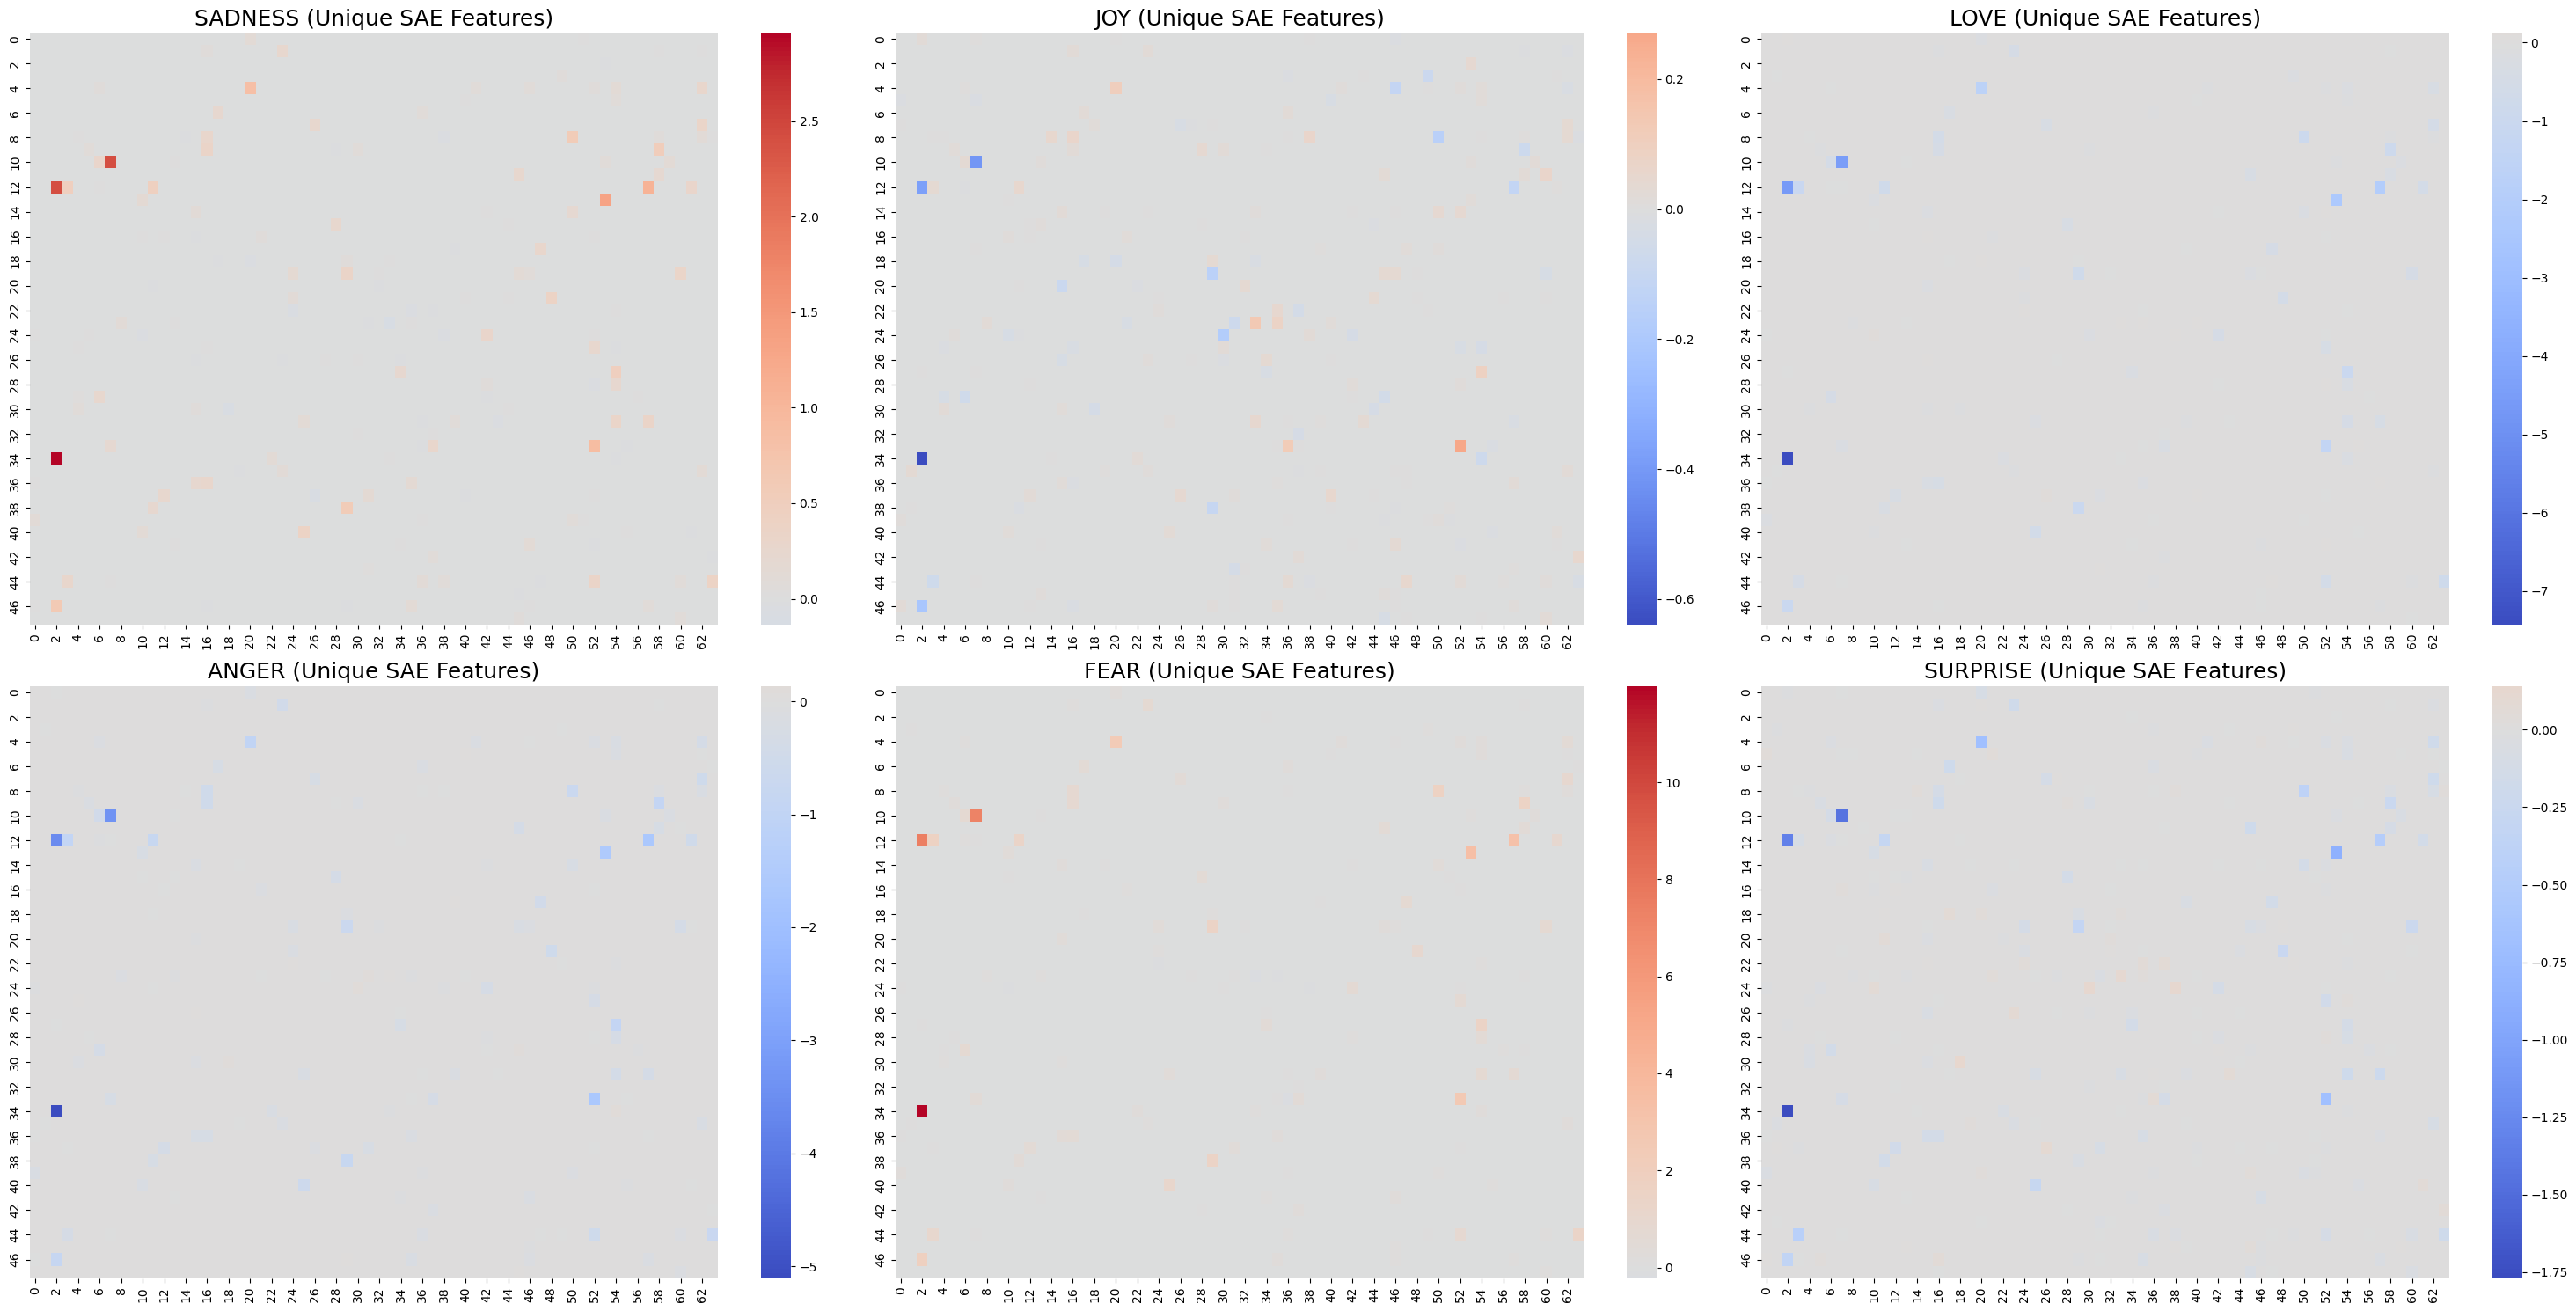

In [237]:
# > 🤖 **AI-Assisted** — Emotion Pattern Analysis (Test Set)
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

# 1. Load Test Dataset
ds_test = load_dataset("dair-ai/emotion", split="test")

sae_model.eval()
test_encoded_by_label = {i: [] for i in range(6)}

batch_size = 64
tokenizer.pad_token = tokenizer.eos_token
target_module._forward_hooks.clear() # Ensure no residual hooks

# 2. Extract SAE Features for Test Set
print("Extracting SAE features for Test Set...")
for i in range(0, len(ds_test["text"]), batch_size):
    batch_texts = ds_test["text"][i:i+batch_size]
    batch_labels = ds_test["label"][i:i+batch_size]
    tokens = tokenizer(batch_texts, max_length=128, truncation=True, padding=True, return_tensors="pt").to(device)

    with torch.inference_mode():
        outputs = model(tokens["input_ids"], output_hidden_states=True)
        gpt_acts = outputs.hidden_states[7]

        # Mean pool unpadded tokens
        mask = tokens["attention_mask"].unsqueeze(-1)
        gpt_acts = (gpt_acts * mask).sum(dim=1) / mask.sum(dim=1)

        _, encoded = sae_model(gpt_acts)
        encoded = encoded.cpu()

        # Group by label
        for j, label in enumerate(batch_labels):
            test_encoded_by_label[label].append(encoded[j])

# 3. Calculate Mean Feature Activation per Emotion
avg_sae_emo_mat = {}
for i in range(6):
    if len(test_encoded_by_label[i]) > 0:
        stacked = torch.stack(test_encoded_by_label[i]) # [num_samples_for_label, 6144]
        avg_sae_emo_mat[i] = stacked.mean(dim=0) # [6144]

# Calculate the GLOBAL average across all emotions
global_avg = torch.stack(list(avg_sae_emo_mat.values())).mean(dim=0)

# 4. Find the most unique features per emotion and plot!
html_output = "<div style='font-family: Arial, sans-serif; max-width: 800px; margin: 0 auto; padding: 20px; background-color: #1e1e1e; color: #ffffff; border-radius: 10px;'>"
html_output += "<h2 style='color: #61dafb; border-bottom: 2px solid #61dafb; padding-bottom: 10px;'>SAE Emotion-Specific Features (Differential Analysis)</h2>"

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(30, 15))
axes_flat = axes.flatten()

for i in range(6):
    emo_name = emotion_mapping[i]
    avg_feats = avg_sae_emo_mat[i]

    # Calculate specificity: How much HIGHER is this feature here compared to the global average?
    specificity = avg_feats - global_avg

    # Reshape the 3072 features into a 48x64 matrix (just like you did 24x32 for GPT-2!)
    heatmap_matrix = specificity.view(48, 64).numpy()

    # Plot heatmap
    ax = axes_flat[i]
    sns.heatmap(heatmap_matrix, ax=ax, cmap="coolwarm", center=0)
    ax.set_title(f"{emo_name.upper()} (Unique SAE Features)", fontsize=18)

    # Get top 5 most UNIQUE features for this emotion
    top_vals, top_idx = torch.topk(specificity, k=5)

    html_output += f"<div style='margin-top: 20px; padding: 15px; border-left: 4px solid #e91e63; background: #2d2d2d; border-radius: 4px;'>"
    html_output += f"<h3 style='color: #e91e63; margin-top: 0;'>{emo_name.upper()}</h3>"
    html_output += "<p style='margin: 5px 0; color: #ccc;'>Top UNIQUE features (Relative difference to baseline):</p>"
    html_output += "<ul style='color: #a5d6a7; margin: 0; padding-left: 20px;'>"
    for val, idx in zip(top_vals, top_idx):
        absolute_val = avg_feats[idx].item()
        html_output += f"<li>Feature #{idx.item()} (Relative jump: +{val.item():.4f} | Absolute avg: {absolute_val:.2f})</li>"
    html_output += "</ul></div>"

plt.tight_layout()
plt.show()

html_output += "</div>"
display(HTML(html_output))




> 🤖 **AI-Assisted** — UI and visualizations

In [241]:
# > 🤖 **AI-Assisted** — Annotated Interpretability Showcase
from IPython.display import display, HTML
import torch
from datasets import load_dataset
import re

# 1. Grab test texts
ds_test = load_dataset("dair-ai/emotion", split="test")
sample_texts = ds_test["text"][:3000]
sample_labels = ds_test["label"][:3000]

try:
    sae_model.eval()
    model_to_use = sae_model
except NameError:
    sae.eval()
    model_to_use = sae

all_encoded = []
batch_size = 64
tokenizer.pad_token = tokenizer.eos_token
target_module._forward_hooks.clear()

# 2. Extract SAE features
print(f"Extracting SAE features for {len(sample_texts)} texts...")
for i in range(0, len(sample_texts), batch_size):
    batch_texts = sample_texts[i:i+batch_size]
    tokens = tokenizer(batch_texts, max_length=128, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.inference_mode():
        outputs = model(tokens["input_ids"], output_hidden_states=True)
        gpt_acts = outputs.hidden_states[7]
        mask = tokens["attention_mask"].unsqueeze(-1)
        gpt_acts = (gpt_acts * mask).sum(dim=1) / mask.sum(dim=1)
        _, encoded = model_to_use(gpt_acts)
        all_encoded.append(encoded.cpu())

encoded_matrix_deep_dive = torch.cat(all_encoded, dim=0)

# 3. Hand-Annotated Interpretability Dictionary
annotations = {
    1505: {
        "name": "The 'Honored / Appreciated' Detector",
        "emotions": "JOY",
        "desc": "Fires strongly on expressions of receiving positive social feedback or feeling grateful. Intriguingly, it also weakly fires for being 'pissed off' and 'aggravated'—suggesting it might be a general 'Reaction to External Social Feedback' circuit.",
        "words": ["honoured", "honored", "proud", "grateful", "cared", "accepted", "affectionate", "prestigious", "award"]
    },
    2178: {
        "name": "The 'Frantic / Anxious' Detector",
        "emotions": "SADNESS & FEAR",
        "desc": "A classic example of feature entanglement. To GPT-2, the distress of sadness and the panic of fear share the exact same neural pathway. This feature perfectly isolates high-arousal distress.",
        "words": ["alarmed", "frantic", "scared", "anxious", "nervous", "defeated", "troubled", "uncomfortable"]
    },
    770: {
        "name": "Redundant Circuit (Anxious/Defeated)",
        "emotions": "FEAR",
        "desc": "Notice how this feature activates on the EXACT same sentences as #2178. This is common in SAEs: multiple features often learn slightly different 'flavors' of the exact same concept.",
        "words": ["alarmed", "frantic", "nervous", "defeated", "depressed", "inspired", "creative"]
    },
    1546: {
        "name": "The 'Complex Social Observation' Detector",
        "emotions": "LOVE & SADNESS",
        "desc": "This feature is fascinating. It doesn't detect a simple emotion; it detects multi-clause sentences where the speaker is observing or judging societal groups or complex human behaviors (e.g. <i>'us humans', 'sick people', 'religious people', 'lifestyles'</i>).",
        "words": ["admit", "doomed", "humans", "sick", "people", "lifestyles", "religious", "faith", "supportive", "family", "men"]
    },
    1938: {
        "name": "The 'Interpersonal Dialogue' Detector",
        "emotions": "SURPRISE & LOVE",
        "desc": "A purely syntactic/narrative feature! It fires heavily on texts that involve talking to someone else or recounting a conversation.",
        "words": ["replied", "said", "told", "asked", "murmur", "banter", "orders", "demonstrate"]
    },
    2230: {
        "name": "The 'Compound Adjective' Detector",
        "emotions": "ANGER",
        "desc": "Look closely at the grammar here. This feature almost exclusively fires on texts that list TWO contrasting or complementary adjectives connected by 'and' (<i>crampy and cranky, jaded and bored, gloomy and confused, grounded and centered</i>).",
        "words": ["productive and creative", "crampy and cranky", "pissed off and angry", "jaded and bored", "complacent and satisfied", "gloomy and confused", "grounded and centered", "impatient and annoyingly", "bouncy and twitchy"]
    },
    2394: {
        "name": "The 'Deep Connection / With You' Detector",
        "emotions": "LOVE",
        "desc": "Fires strongly on profound relationship-focused sentences, especially those directed at a specific 'you' (<i>with you, without you, by you</i>).",
        "words": ["disappointed by you", "without you", "with you", "with his love", "marriage to", "our decision", "divine with you", "trusts me", "share it with you"]
    },
    1566: {
        "name": "The 'Things / Anything' Syntactic Detector",
        "emotions": "ANGER & SURPRISE",
        "desc": "The ultimate plot twist! This has nothing to do with emotion. It is a linguistic detector for indefinite pronouns. It fires whenever the text contains words like <i>anything, everything, something, or things</i>.",
        "words": ["anything", "everything", "something", "nothing", "things"]
    }
}

target_features = list(annotations.keys())

# 4. Build the final visual UI
def generate_feature_html(feat_idx, encoded_matrix, sample_texts, sample_labels):
    data = annotations[feat_idx]

    feature_activations = encoded_matrix[:, feat_idx]
    top_values, top_indices = torch.topk(feature_activations, k=10)

    # Container
    html = f"<div style='margin-bottom: 40px; background: #ffffff; border-radius: 12px; overflow: hidden; box-shadow: 0 4px 15px rgba(0,0,0,0.05); border: 1px solid #e0e0e0;'>"

    # Header
    html += f"<div style='background: #f8f9fa; padding: 20px; border-bottom: 1px solid #e0e0e0; display: flex; justify-content: space-between; align-items: center;'>"
    html += f"<h2 style='margin: 0; color: #333333; font-size: 1.6em;'>Feature <span style='color: #1a73e8;'>#{feat_idx}</span> — {data['name']}</h2>"
    html += f"<span style='background: #e8f0fe; color: #1a73e8; padding: 6px 14px; border-radius: 20px; font-weight: bold; font-size: 0.9em;'>Core: {data['emotions']}</span>"
    html += "</div>"

    # Annotation
    html += f"<div style='padding: 20px; background: #ffffff; border-bottom: 1px solid #f0f0f0;'>"
    html += f"<h4 style='margin: 0 0 10px 0; color: #1a73e8; font-weight: 600; text-transform: uppercase; font-size: 0.85em; letter-spacing: 1px;'>Analysis:</h4>"
    html += f"<p style='margin: 0; color: #444; font-size: 1.1em; line-height: 1.5;'>{data['desc']}</p>"
    html += "</div>"

    # Texts
    html += "<div style='padding: 10px 20px 20px 20px; background: #fafafa;'>"
    for val, idx in zip(top_values, top_indices):
        text = sample_texts[idx.item()]
        label = emotion_mapping.get(sample_labels[idx.item()], "unknown")
        act_val = val.item()

        # Highlight key words
        highlighted_text = text
        for word in data['words']:
            # Replace case-insensitive and handle spaces for multi-word phrases
            pattern = re.compile(r'\b(' + re.escape(word) + r')\b', re.IGNORECASE)
            highlighted_text = pattern.sub(r"<span style='color: #d32f2f; font-weight: bold; background: #fce8e6; padding: 2px 4px; border-radius: 4px;'>\1</span>", highlighted_text)

        html += f"""
            <div style="margin-top: 15px; padding: 15px; background: #ffffff; border-left: 4px solid #1a73e8; border-radius: 0 6px 6px 0; box-shadow: 0 2px 4px rgba(0,0,0,0.02); border: 1px solid #f0f0f0;">
                <div style="margin-bottom: 8px; display: flex; justify-content: space-between;">
                    <span style="color: #5f6368; font-size: 0.85em; font-weight: bold; letter-spacing: 1px;">{label.upper()}</span>
                    <span style="color: #1a73e8; font-weight: bold; font-family: monospace; font-size: 0.9em;">ACT: {act_val:.2f}</span>
                </div>
                <div style="font-size: 1.15em; line-height: 1.6; color: #202124; letter-spacing: 0.2px;">{highlighted_text}</div>
            </div>
        """
    html += "</div></div>"
    return html

# Build final page
main_html = "<div style='font-family: Arial, sans-serif; max-width: 900px; margin: 0 auto; padding: 30px; background: #f9fafb; color: #333333; border-radius: 15px; border: 1px solid #e0e0e0;'>"
main_html += "<div style='text-align: center; margin-bottom: 40px;'>"
main_html += "<h1 style='color: #1a73e8; margin-bottom: 10px; font-size: 2.2em; letter-spacing: 1px;'>Reverse-Engineering GPT-2</h1>"
main_html += "<p style='color: #5f6368; font-size: 1.1em; max-width: 700px; margin: 0 auto;'>A heavily annotated breakdown of the most fascinating features discovered by the Sparse Autoencoder.</p>"
main_html += "</div>"

for feat_idx in target_features:
    main_html += generate_feature_html(feat_idx, encoded_matrix_deep_dive, sample_texts, sample_labels)

main_html += "</div>"
display(HTML(main_html))



Extracting SAE features for 2000 texts...


> ✍️ **My Work** — Executing code block